In [1]:
import os
import re
import glob
import random
import numpy as np
import pickle
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
LGG_DATASET_ROOT = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'

GAN_HEATMAPS_NPY = None

GAN_HEATMAPS_FOLDER = '/kaggle/input/datasets/hamsaa123/lastweek-outputs/lgg_outputs/heatmaps_gan'

# Path to abnormal_samples.pkl — list/array of filenames or indices
# that identify which samples are abnormal (have a tumor present)
ABNORMAL_SAMPLES_PKL = '/kaggle/input/datasets/hamsaa123/lastweek-outputs/lgg_outputs/abnormal_samples.pkl'

# Output directory (Kaggle working dir is writable)
OUTPUT_DIR = '/kaggle/working/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Image settings
IMG_SIZE   = 256    # Resize all images to IMG_SIZE x IMG_SIZE
BATCH_SIZE = 8
NUM_EPOCHS = 30
LR         = 1e-4
TRAIN_SPLIT = 0.8   # 80% train, 20% test

print('Paths configured.')

Paths configured.


In [3]:
# The LGG dataset stores each patient in a TCGA_* folder.
# Inside each folder: *_<slice>.tif  (MRI image) and *_<slice>_mask.tif (ground truth mask).
# Abnormal images are those whose mask contains at least one positive (tumor) pixel.

def collect_all_pairs(dataset_root):
    """
    Walk through every TCGA patient folder and collect (image_path, mask_path) pairs.
    Mask files follow the naming convention: <stem>_mask.tif
    """
    pairs = []
    for patient_dir in sorted(glob.glob(os.path.join(dataset_root, 'TCGA_*'))):
        # All .tif files that are NOT masks
        image_files = sorted([
            f for f in glob.glob(os.path.join(patient_dir, '*.tif'))
            if '_mask' not in os.path.basename(f)
        ])
        for img_path in image_files:
            stem      = img_path.replace('.tif', '')
            mask_path = stem + '_mask.tif'
            if os.path.exists(mask_path):
                pairs.append((img_path, mask_path))
    return pairs


def filter_abnormal(pairs):
    """
    Keep only (image, mask) pairs where the mask has at least one positive pixel.
    This identifies slices that actually contain a tumor region.
    """
    abnormal = []
    for img_path, mask_path in pairs:
        mask = np.array(Image.open(mask_path).convert('L'))
        if mask.max() > 0:          # at least one tumor pixel
            abnormal.append((img_path, mask_path))
    return abnormal


print('Collecting all image-mask pairs...')
all_pairs      = collect_all_pairs(LGG_DATASET_ROOT)
print(f'  Total pairs found: {len(all_pairs)}')

print('Filtering to abnormal (tumor-present) slices...')
abnormal_pairs = filter_abnormal(all_pairs)
print(f'  Abnormal pairs: {len(abnormal_pairs)}')

  Total pairs found: 3929
Filtering to abnormal (tumor-present) slices...
  Abnormal pairs: 1373


In [4]:
# The GAN heatmaps were generated last week for each abnormal slice.
# We need to align each heatmap to its corresponding (image, mask) pair.

def load_heatmaps(npy_path, folder_path, abnormal_pairs):
    """
    Returns a dict: { img_path -> heatmap_array (H x W, float32) }
    Supports two storage formats: single .npy array or per-file folder.
    """
    heatmap_index = {}

    if npy_path is not None and os.path.exists(npy_path):
        # --- Format A: single stacked array (N, H, W) or (N, 1, H, W) ---
        data = np.load(npy_path)                        # load full array
        if data.ndim == 4:
            data = data[:, 0, :, :]                     # drop channel dim
        assert len(data) == len(abnormal_pairs), (
            f'Heatmap count ({len(data)}) does not match '
            f'abnormal pairs count ({len(abnormal_pairs)}). '
            'Ensure both follow the same sort order.'
        )
        for i, (img_path, _) in enumerate(abnormal_pairs):
            heatmap_index[img_path] = data[i].astype(np.float32)
        print(f'Loaded {len(data)} heatmaps from single .npy file.')

    elif folder_path is not None and os.path.isdir(folder_path):
        # --- Format B: individual .npy files, one per slice ---
        for img_path, _ in abnormal_pairs:
            stem      = os.path.splitext(os.path.basename(img_path))[0]
            heat_file = os.path.join(folder_path, stem + '_gan_heatmap.npy')
            if os.path.exists(heat_file):
                arr = np.load(heat_file).astype(np.float32)
                if arr.ndim == 3:
                    arr = arr[0]                        # (1, H, W) -> (H, W)
                heatmap_index[img_path] = arr
        print(f'Loaded {len(heatmap_index)} heatmaps from folder.')

    else:
        raise FileNotFoundError(
            'Could not find heatmaps. Check GAN_HEATMAPS_NPY or GAN_HEATMAPS_FOLDER.'
        )

    return heatmap_index


heatmap_index = load_heatmaps(GAN_HEATMAPS_NPY, GAN_HEATMAPS_FOLDER, abnormal_pairs)

# Sanity check: verify shapes
sample_key  = list(heatmap_index.keys())[0]
sample_heat = heatmap_index[sample_key]
print(f'Sample heatmap shape: {sample_heat.shape}, dtype: {sample_heat.dtype}')

Loaded 1373 heatmaps from folder.
Sample heatmap shape: (128, 128), dtype: float32


In [5]:
class LGGBaselineDataset(Dataset):
    """
    Approach 1 Dataset: returns (image_tensor, mask_tensor).
    Image is a 3-channel RGB tensor; mask is a single-channel binary tensor.
    """
    def __init__(self, pairs, img_size=256):
        self.pairs    = pairs
        self.img_size = img_size
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),              # [0,255] -> [0,1], shape (C, H, W)
            transforms.Normalize(               # ImageNet stats (reasonable default for MRI)
                mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]
            ),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # Load MRI image as RGB
        image = Image.open(img_path).convert('RGB')
        image = self.img_transform(image)       # (3, H, W)

        # Load mask as grayscale, then binarize
        mask  = Image.open(mask_path).convert('L')
        mask  = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask  = torch.tensor(np.array(mask), dtype=torch.float32).unsqueeze(0)  # (1, H, W)
        mask  = (mask > 0).float()              # ensure binary {0, 1}

        return image, mask


class LGGHeatmapDataset(Dataset):
    """
    Approach 2 Dataset: returns (image+heatmap_tensor, mask_tensor).
    The GAN heatmap is appended as a 4th channel to the image tensor.
    Input tensor shape: (4, H, W)
    """
    def __init__(self, pairs, heatmap_index, img_size=256):
        # Only keep pairs for which a heatmap actually exists
        self.pairs         = [(p, m) for (p, m) in pairs if p in heatmap_index]
        self.heatmap_index = heatmap_index
        self.img_size      = img_size
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # --- RGB image ---
        image = Image.open(img_path).convert('RGB')
        image = self.img_transform(image)           # (3, H, W)

        # --- GAN heatmap as 4th channel ---
        heatmap = self.heatmap_index[img_path]       # (H_orig, W_orig) float32
        heatmap = Image.fromarray(heatmap)           # PIL float image
        heatmap = heatmap.resize((self.img_size, self.img_size), Image.BILINEAR)
        heatmap = torch.tensor(np.array(heatmap), dtype=torch.float32).unsqueeze(0)  # (1, H, W)
        # Normalize heatmap to [0, 1]
        hmin, hmax = heatmap.min(), heatmap.max()
        if hmax > hmin:
            heatmap = (heatmap - hmin) / (hmax - hmin)

        # Concatenate along channel dim: (3+1, H, W) = (4, H, W)
        combined = torch.cat([image, heatmap], dim=0)

        # --- Ground truth mask ---
        mask = Image.open(mask_path).convert('L')
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = torch.tensor(np.array(mask), dtype=torch.float32).unsqueeze(0)
        mask = (mask > 0).float()

        return combined, mask


print('Dataset classes defined.')

Dataset classes defined.


In [6]:
PIN_MEM = DEVICE.type == "cuda"
# Deterministic shuffle then split
random.shuffle(abnormal_pairs)

split_idx   = int(len(abnormal_pairs) * TRAIN_SPLIT)
train_pairs = abnormal_pairs[:split_idx]
test_pairs  = abnormal_pairs[split_idx:]

print(f'Total abnormal slices : {len(abnormal_pairs)}')
print(f'  Training set        : {len(train_pairs)}')
print(f'  Test set            : {len(test_pairs)}')

# --- Approach 1 DataLoaders ---
train_dataset_A1 = LGGBaselineDataset(train_pairs, IMG_SIZE)
test_dataset_A1  = LGGBaselineDataset(test_pairs,  IMG_SIZE)

train_loader_A1  = DataLoader(train_dataset_A1, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=PIN_MEM)
test_loader_A1   = DataLoader(test_dataset_A1,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEM)

# --- Approach 2 DataLoaders ---
train_dataset_A2 = LGGHeatmapDataset(train_pairs, heatmap_index, IMG_SIZE)
test_dataset_A2  = LGGHeatmapDataset(test_pairs,  heatmap_index, IMG_SIZE)

train_loader_A2  = DataLoader(train_dataset_A2, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=PIN_MEM)
test_loader_A2   = DataLoader(test_dataset_A2,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEM)

print('DataLoaders ready.')

Total abnormal slices : 1373
  Training set        : 1098
  Test set            : 275
DataLoaders ready.


In [7]:
# Standard UNet with configurable input channels.
# in_channels=3 for Approach 1 (RGB only)
# in_channels=4 for Approach 2 (RGB + heatmap)

class DoubleConv(nn.Module):
    """Two consecutive Conv -> BatchNorm -> ReLU blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """MaxPool -> DoubleConv (encoder step)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    """Bilinear upsample + skip connection + DoubleConv (decoder step)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Handle spatial size mismatch from skip connection
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([skip, x], dim=1)     # concatenate skip features
        return self.conv(x)


class UNet(nn.Module):
    """
    UNet for binary segmentation.
    in_channels : 3 (baseline) or 4 (heatmap-guided)
    """
    def __init__(self, in_channels=3, base_features=64):
        super().__init__()
        f = base_features         # shorthand

        # Encoder
        self.enc1 = DoubleConv(in_channels, f)      # 256 -> 256
        self.enc2 = Down(f,    f*2)                 # 256 -> 128
        self.enc3 = Down(f*2,  f*4)                 # 128 -> 64
        self.enc4 = Down(f*4,  f*8)                 # 64  -> 32

        # Bottleneck
        self.bottleneck = Down(f*8, f*16)           # 32  -> 16

        # Decoder
        self.dec4 = Up(f*16 + f*8,  f*8)           # 16  -> 32
        self.dec3 = Up(f*8  + f*4,  f*4)           # 32  -> 64
        self.dec2 = Up(f*4  + f*2,  f*2)           # 64  -> 128
        self.dec1 = Up(f*2  + f,    f)              # 128 -> 256

        # Final 1x1 convolution -> single channel binary output
        self.out_conv = nn.Conv2d(f, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)           # skip 1
        s2 = self.enc2(s1)          # skip 2
        s3 = self.enc3(s2)          # skip 3
        s4 = self.enc4(s3)          # skip 4

        b  = self.bottleneck(s4)    # bottleneck

        d  = self.dec4(b,  s4)
        d  = self.dec3(d,  s3)
        d  = self.dec2(d,  s2)
        d  = self.dec1(d,  s1)

        return self.out_conv(d)     # raw logits, shape (B, 1, H, W)


# Quick parameter count check
model_check = UNet(in_channels=3)
total_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'UNet (3-ch) trainable parameters: {total_params:,}')

model_check = UNet(in_channels=4)
total_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'UNet (4-ch) trainable parameters: {total_params:,}')

UNet (3-ch) trainable parameters: 31,384,833
UNet (4-ch) trainable parameters: 31,385,409


In [8]:
# Binary Cross Entropy Loss
# Works on raw logits via BCEWithLogitsLoss (numerically stable).

bce_loss_fn = nn.BCEWithLogitsLoss()


def dice_loss(logits, targets, smooth=1.0):
    """
    Soft Dice Loss computed on sigmoid-activated predictions.
    smooth: Laplace smoothing constant to avoid division by zero.
    """
    probs = torch.sigmoid(logits)                    # (B, 1, H, W)
    # Flatten spatial dimensions for batch-wise computation
    probs   = probs.view(probs.size(0), -1)          # (B, H*W)
    targets = targets.view(targets.size(0), -1)      # (B, H*W)

    intersection = (probs * targets).sum(dim=1)      # (B,)
    dice = (2.0 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )
    return 1.0 - dice.mean()                         # scalar


def combined_loss(logits, targets, bce_weight=0.5, dice_weight=0.5):
    """
    Combined loss = bce_weight * BCE + dice_weight * Dice.
    Default: equal weighting. Adjust via bce_weight/dice_weight.
    """
    bce  = bce_loss_fn(logits, targets)
    dice = dice_loss(logits, targets)
    return bce_weight * bce + dice_weight * dice


def compute_dice_score(preds_binary, targets):
    """
    Hard Dice Score for evaluation.
    preds_binary: thresholded predictions {0, 1} (B, 1, H, W)
    targets     : ground truth masks       {0, 1} (B, 1, H, W)
    Returns mean Dice score over the batch.
    """
    smooth = 1e-6
    p = preds_binary.view(preds_binary.size(0), -1).float()
    t = targets.view(targets.size(0), -1).float()
    intersection = (p * t).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (p.sum(dim=1) + t.sum(dim=1) + smooth)
    return dice.mean().item()


def compute_iou(preds_binary, targets):
    """
    Intersection over Union for evaluation.
    """
    smooth = 1e-6
    p = preds_binary.view(preds_binary.size(0), -1).float()
    t = targets.view(targets.size(0), -1).float()
    intersection = (p * t).sum(dim=1)
    union        = (p + t - p * t).sum(dim=1)
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()


print('Loss functions and metrics defined.')

Loss functions and metrics defined.


In [9]:
def train_one_epoch(model, loader, optimizer):
    """
    Run a single training epoch.
    Returns: average loss over all batches.
    """
    model.train()
    epoch_loss = 0.0
    for images, masks in loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)                  # forward pass
        loss   = combined_loss(logits, masks)   # BCE + Dice
        loss.backward()                         # backprop
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate(model, loader, threshold=0.5):
    """
    Evaluate on the given DataLoader.
    Returns: (avg_loss, avg_dice, avg_iou)
    """
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou  = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)

            logits        = model(images)
            loss          = combined_loss(logits, masks)
            preds_binary  = (torch.sigmoid(logits) > threshold).float()

            total_loss += loss.item()
            total_dice += compute_dice_score(preds_binary, masks)
            total_iou  += compute_iou(preds_binary, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


def run_training(model, train_loader, test_loader, num_epochs, lr, label):
    """
    Full training run for a given model.
    Returns history dict with loss, dice, iou per epoch.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # ReduceLROnPlateau decays LR when test loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'test_loss': [], 'test_dice': [], 'test_iou': []}
    best_dice = 0.0
    best_path = os.path.join(OUTPUT_DIR, f'best_{label}.pth')

    print(f'\n--- Training: {label} ---')
    for epoch in range(1, num_epochs + 1):
        train_loss             = train_one_epoch(model, train_loader, optimizer)
        test_loss, dice, iou   = evaluate(model, test_loader)
        scheduler.step(test_loss)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_dice'].append(dice)
        history['test_iou'].append(iou)

        # Save checkpoint when test Dice improves
        if dice > best_dice:
            best_dice = dice
            torch.save(model.state_dict(), best_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:03d}/{num_epochs}  '
                  f'Train Loss: {train_loss:.4f}  '
                  f'Test Loss: {test_loss:.4f}  '
                  f'Dice: {dice:.4f}  IoU: {iou:.4f}')

    print(f'Best Dice ({label}): {best_dice:.4f}  [saved to {best_path}]')
    return history, best_path


print('Training utilities defined.')

Training utilities defined.


In [10]:
model_A1 = UNet(in_channels=3).to(DEVICE)

history_A1, best_path_A1 = run_training(
    model     = model_A1,
    train_loader = train_loader_A1,
    test_loader  = test_loader_A1,
    num_epochs   = NUM_EPOCHS,
    lr           = LR,
    label        = 'approach1_baseline'
)


--- Training: approach1_baseline ---
  Epoch 001/30  Train Loss: 0.6181  Test Loss: 0.5829  Dice: 0.5559  IoU: 0.4256
  Epoch 005/30  Train Loss: 0.4218  Test Loss: 0.4047  Dice: 0.7324  IoU: 0.6255
  Epoch 010/30  Train Loss: 0.2454  Test Loss: 0.2366  Dice: 0.7828  IoU: 0.6852
  Epoch 015/30  Train Loss: 0.1361  Test Loss: 0.1442  Dice: 0.8143  IoU: 0.7277
  Epoch 020/30  Train Loss: 0.1004  Test Loss: 0.1204  Dice: 0.8224  IoU: 0.7399
  Epoch 025/30  Train Loss: 0.0855  Test Loss: 0.1056  Dice: 0.8331  IoU: 0.7494
  Epoch 030/30  Train Loss: 0.0803  Test Loss: 0.1104  Dice: 0.8171  IoU: 0.7316
Best Dice (approach1_baseline): 0.8331  [saved to /kaggle/working/results/best_approach1_baseline.pth]


In [11]:
model_A2 = UNet(in_channels=4).to(DEVICE)

history_A2, best_path_A2 = run_training(
    model        = model_A2,
    train_loader = train_loader_A2,
    test_loader  = test_loader_A2,
    num_epochs   = NUM_EPOCHS,
    lr           = LR,
    label        = 'approach2_heatmap_guided'
)


--- Training: approach2_heatmap_guided ---
  Epoch 001/30  Train Loss: 0.5857  Test Loss: 0.5467  Dice: 0.5860  IoU: 0.4757
  Epoch 005/30  Train Loss: 0.3867  Test Loss: 0.3701  Dice: 0.7044  IoU: 0.5893
  Epoch 010/30  Train Loss: 0.2202  Test Loss: 0.2160  Dice: 0.7650  IoU: 0.6709
  Epoch 015/30  Train Loss: 0.1382  Test Loss: 0.1693  Dice: 0.7694  IoU: 0.6713
  Epoch 020/30  Train Loss: 0.1073  Test Loss: 0.1219  Dice: 0.8157  IoU: 0.7270
  Epoch 025/30  Train Loss: 0.0843  Test Loss: 0.1083  Dice: 0.8261  IoU: 0.7435
  Epoch 030/30  Train Loss: 0.0877  Test Loss: 0.1035  Dice: 0.8262  IoU: 0.7444
Best Dice (approach2_heatmap_guided): 0.8286  [saved to /kaggle/working/results/best_approach2_heatmap_guided.pth]


In [12]:
# Load the best-validation checkpoints saved during training
model_A1.load_state_dict(torch.load(best_path_A1, map_location=DEVICE))
model_A2.load_state_dict(torch.load(best_path_A2, map_location=DEVICE))

_, final_dice_A1, final_iou_A1 = evaluate(model_A1, test_loader_A1)
_, final_dice_A2, final_iou_A2 = evaluate(model_A2, test_loader_A2)

print('\n=== Final Test Set Results ===')
print(f'Approach 1 (Baseline)         Dice: {final_dice_A1:.4f}  IoU: {final_iou_A1:.4f}')
print(f'Approach 2 (Heatmap-Guided)   Dice: {final_dice_A2:.4f}  IoU: {final_iou_A2:.4f}')


=== Final Test Set Results ===
Approach 1 (Baseline)         Dice: 0.8331  IoU: 0.7494
Approach 2 (Heatmap-Guided)   Dice: 0.8286  IoU: 0.7429


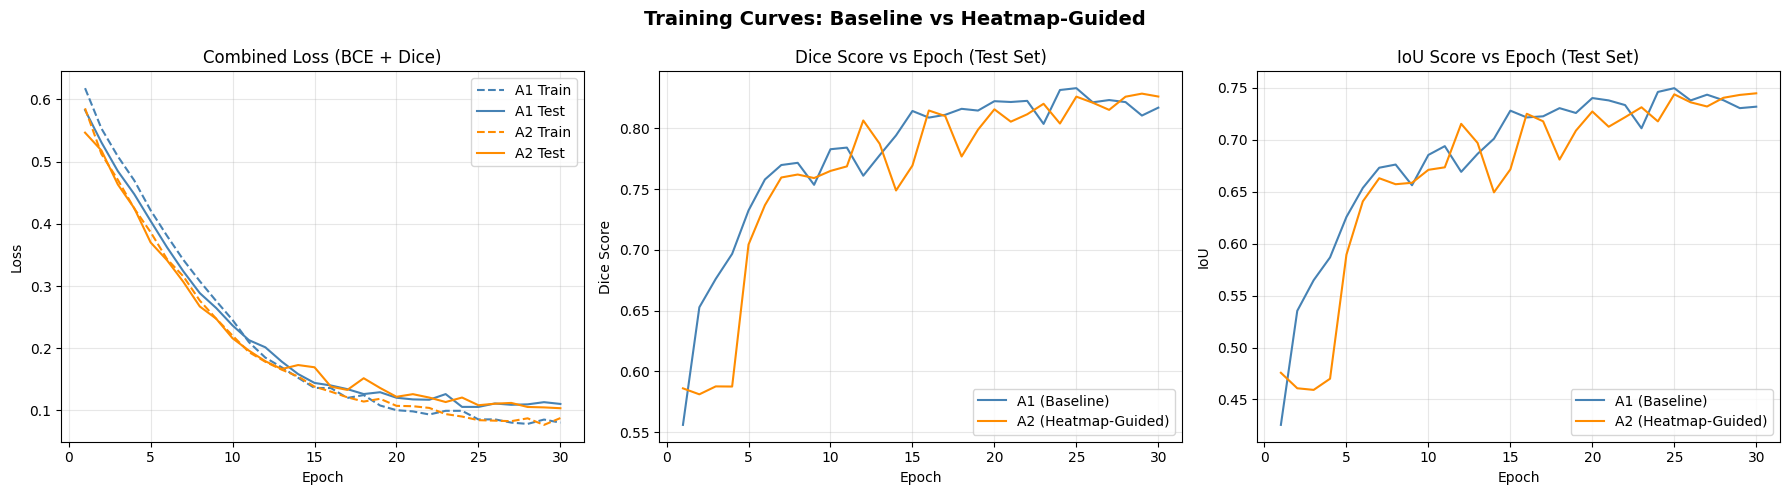

Training curves saved.


In [13]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves: Baseline vs Heatmap-Guided', fontsize=14, fontweight='bold')

# --- Loss ---
ax = axes[0]
ax.plot(epochs, history_A1['train_loss'], label='A1 Train', color='steelblue',   linestyle='--')
ax.plot(epochs, history_A1['test_loss'],  label='A1 Test',  color='steelblue',   linestyle='-')
ax.plot(epochs, history_A2['train_loss'], label='A2 Train', color='darkorange',  linestyle='--')
ax.plot(epochs, history_A2['test_loss'],  label='A2 Test',  color='darkorange',  linestyle='-')
ax.set_title('Combined Loss (BCE + Dice)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Dice Score ---
ax = axes[1]
ax.plot(epochs, history_A1['test_dice'], label='A1 (Baseline)',        color='steelblue')
ax.plot(epochs, history_A2['test_dice'], label='A2 (Heatmap-Guided)',  color='darkorange')
ax.set_title('Dice Score vs Epoch (Test Set)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Score')
ax.legend()
ax.grid(True, alpha=0.3)

# --- IoU ---
ax = axes[2]
ax.plot(epochs, history_A1['test_iou'], label='A1 (Baseline)',       color='steelblue')
ax.plot(epochs, history_A2['test_iou'], label='A2 (Heatmap-Guided)', color='darkorange')
ax.set_title('IoU Score vs Epoch (Test Set)')
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

Saved: /kaggle/working/results/samples_approach1.png


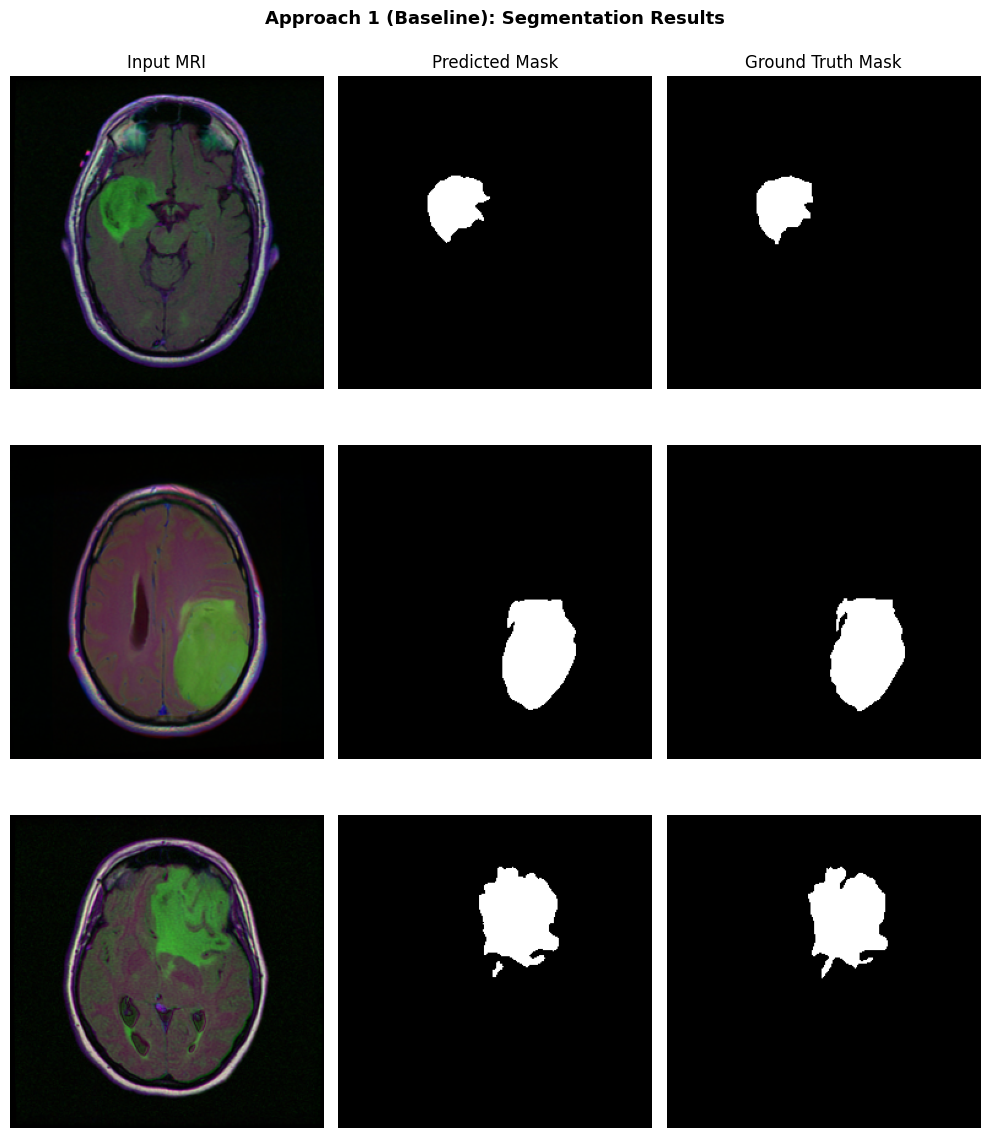

In [14]:
# Denormalization constants (ImageNet)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    return (tensor.cpu() * STD + MEAN).clamp(0, 1)


def visualize_approach1(model, dataset, num_samples=3, threshold=0.5, save_path=None):
    """
    Show: Input MRI | Predicted Mask | Ground Truth Mask
    for num_samples random samples from the dataset.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 4 * num_samples))
    fig.suptitle('Approach 1 (Baseline): Segmentation Results', fontsize=13, fontweight='bold')
    col_titles = ['Input MRI', 'Predicted Mask', 'Ground Truth Mask']

    for row, idx in enumerate(indices):
        image_tensor, mask_tensor = dataset[idx]

        # Run inference
        with torch.no_grad():
            logit = model(image_tensor.unsqueeze(0).to(DEVICE))   # (1, 1, H, W)
            pred  = (torch.sigmoid(logit) > threshold).float().cpu().squeeze()  # (H, W)

        gt   = mask_tensor.squeeze().cpu().numpy()             # (H, W)
        pred_np = pred.numpy()

        # Compute per-sample metrics
        pred_t = torch.tensor(pred_np).unsqueeze(0).unsqueeze(0)
        gt_t   = torch.tensor(gt).unsqueeze(0).unsqueeze(0)
        dice   = compute_dice_score(pred_t, gt_t)
        iou    = compute_iou(pred_t, gt_t)

        # Denormalize image for display (use first 3 channels)
        img_display = denormalize(image_tensor[:3]).permute(1, 2, 0).numpy()

        row_ax = axes[row] if num_samples > 1 else axes

        row_ax[0].imshow(img_display)
        row_ax[0].set_title(col_titles[0] if row == 0 else '')
        row_ax[0].axis('off')

        row_ax[1].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
        row_ax[1].set_title(col_titles[1] if row == 0 else '')
        row_ax[1].set_xlabel(f'Dice: {dice:.3f}  IoU: {iou:.3f}', fontsize=9)
        row_ax[1].axis('off')

        row_ax[2].imshow(gt, cmap='gray', vmin=0, vmax=1)
        row_ax[2].set_title(col_titles[2] if row == 0 else '')
        row_ax[2].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


visualize_approach1(
    model_A1, test_dataset_A1,
    num_samples=3,
    save_path=os.path.join(OUTPUT_DIR, 'samples_approach1.png')
)

Saved: /kaggle/working/results/samples_approach2.png


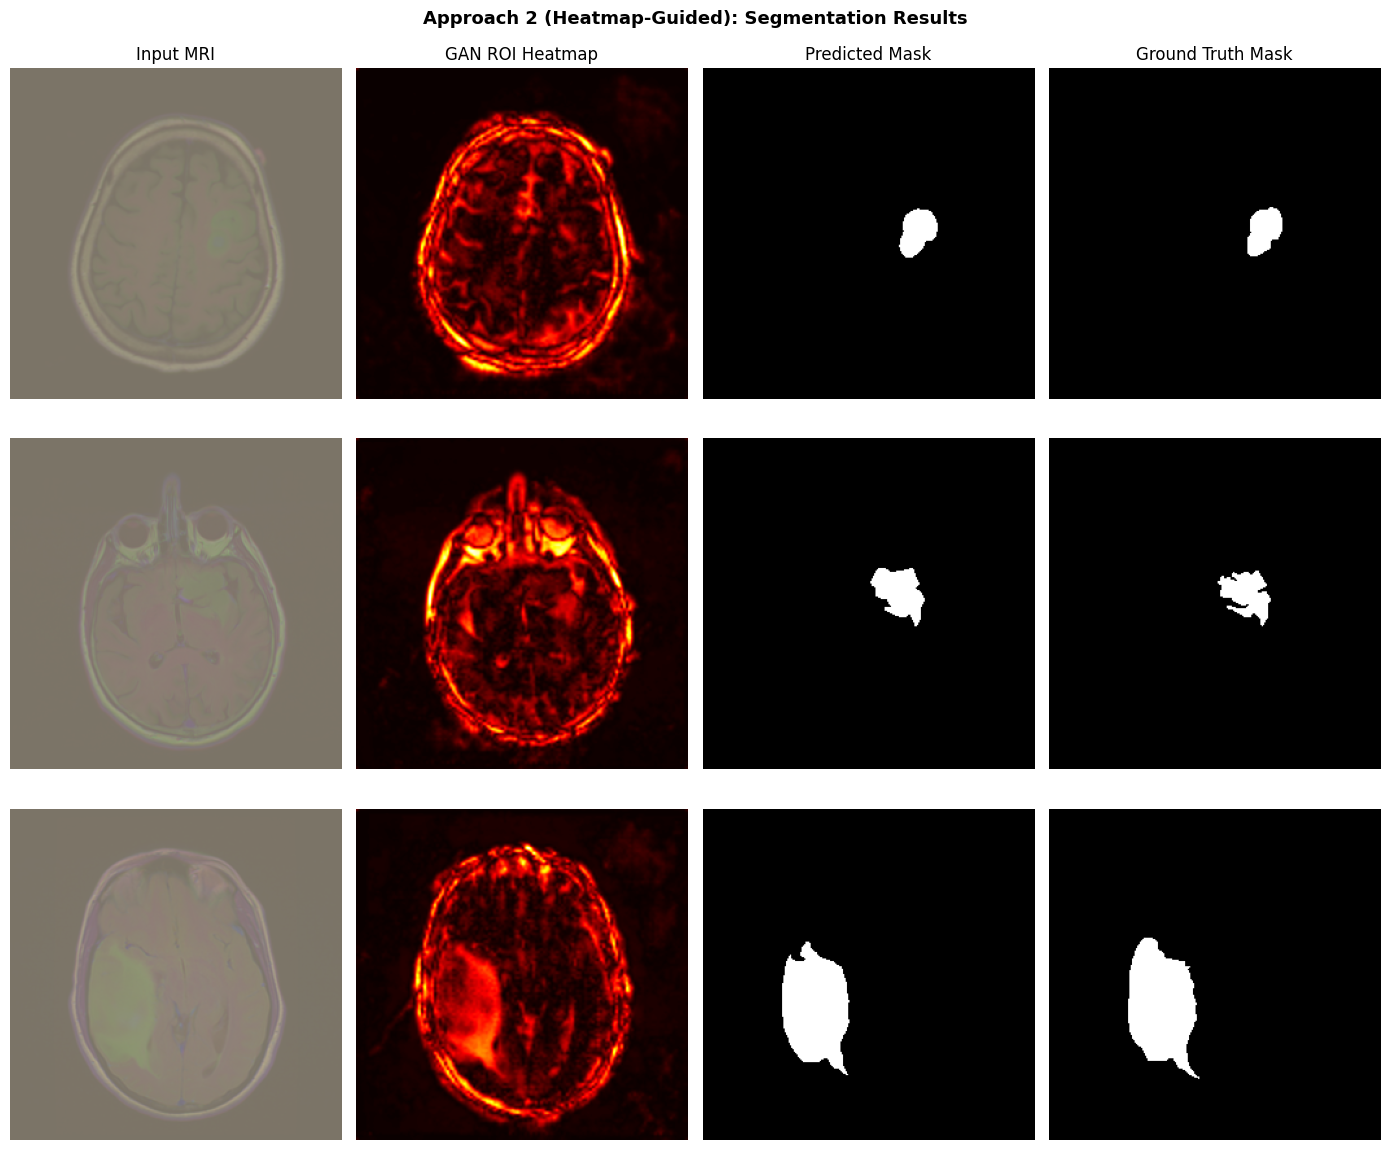

In [15]:
def visualize_approach2(model, dataset, num_samples=3, threshold=0.5, save_path=None):
    """
    Show: Input MRI | ROI Heatmap | Predicted Mask | Ground Truth Mask
    for num_samples random samples from the dataset.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(num_samples, 4, figsize=(14, 4 * num_samples))
    fig.suptitle('Approach 2 (Heatmap-Guided): Segmentation Results', fontsize=13, fontweight='bold')
    col_titles = ['Input MRI', 'GAN ROI Heatmap', 'Predicted Mask', 'Ground Truth Mask']

    for row, idx in enumerate(indices):
        combined_tensor, mask_tensor = dataset[idx]  # (4, H, W), (1, H, W)

        with torch.no_grad():
            logit = model(combined_tensor.unsqueeze(0).to(DEVICE))
            pred  = (torch.sigmoid(logit) > threshold).float().cpu().squeeze()

        gt      = mask_tensor.squeeze().cpu().numpy()
        pred_np = pred.numpy()

        # Per-sample metrics
        pred_t = torch.tensor(pred_np).unsqueeze(0).unsqueeze(0)
        gt_t   = torch.tensor(gt).unsqueeze(0).unsqueeze(0)
        dice   = compute_dice_score(pred_t, gt_t)
        iou    = compute_iou(pred_t, gt_t)

        # Extract sub-tensors for display
        img_display  = denormalize(combined_tensor[:3]).permute(1, 2, 0).numpy()
        heat_display = combined_tensor[3].numpy()   # 4th channel = heatmap

        row_ax = axes[row] if num_samples > 1 else axes

        row_ax[0].imshow(img_display)
        row_ax[0].set_title(col_titles[0] if row == 0 else '')
        row_ax[0].axis('off')

        row_ax[1].imshow(heat_display, cmap='hot')
        row_ax[1].set_title(col_titles[1] if row == 0 else '')
        row_ax[1].axis('off')

        row_ax[2].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
        row_ax[2].set_title(col_titles[2] if row == 0 else '')
        row_ax[2].set_xlabel(f'Dice: {dice:.3f}  IoU: {iou:.3f}', fontsize=9)
        row_ax[2].axis('off')

        row_ax[3].imshow(gt, cmap='gray', vmin=0, vmax=1)
        row_ax[3].set_title(col_titles[3] if row == 0 else '')
        row_ax[3].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


visualize_approach2(
    model_A2, test_dataset_A2,
    num_samples=3,
    save_path=os.path.join(OUTPUT_DIR, 'samples_approach2.png')
)

Saved: /kaggle/working/results/comparison_a1_vs_a2.png


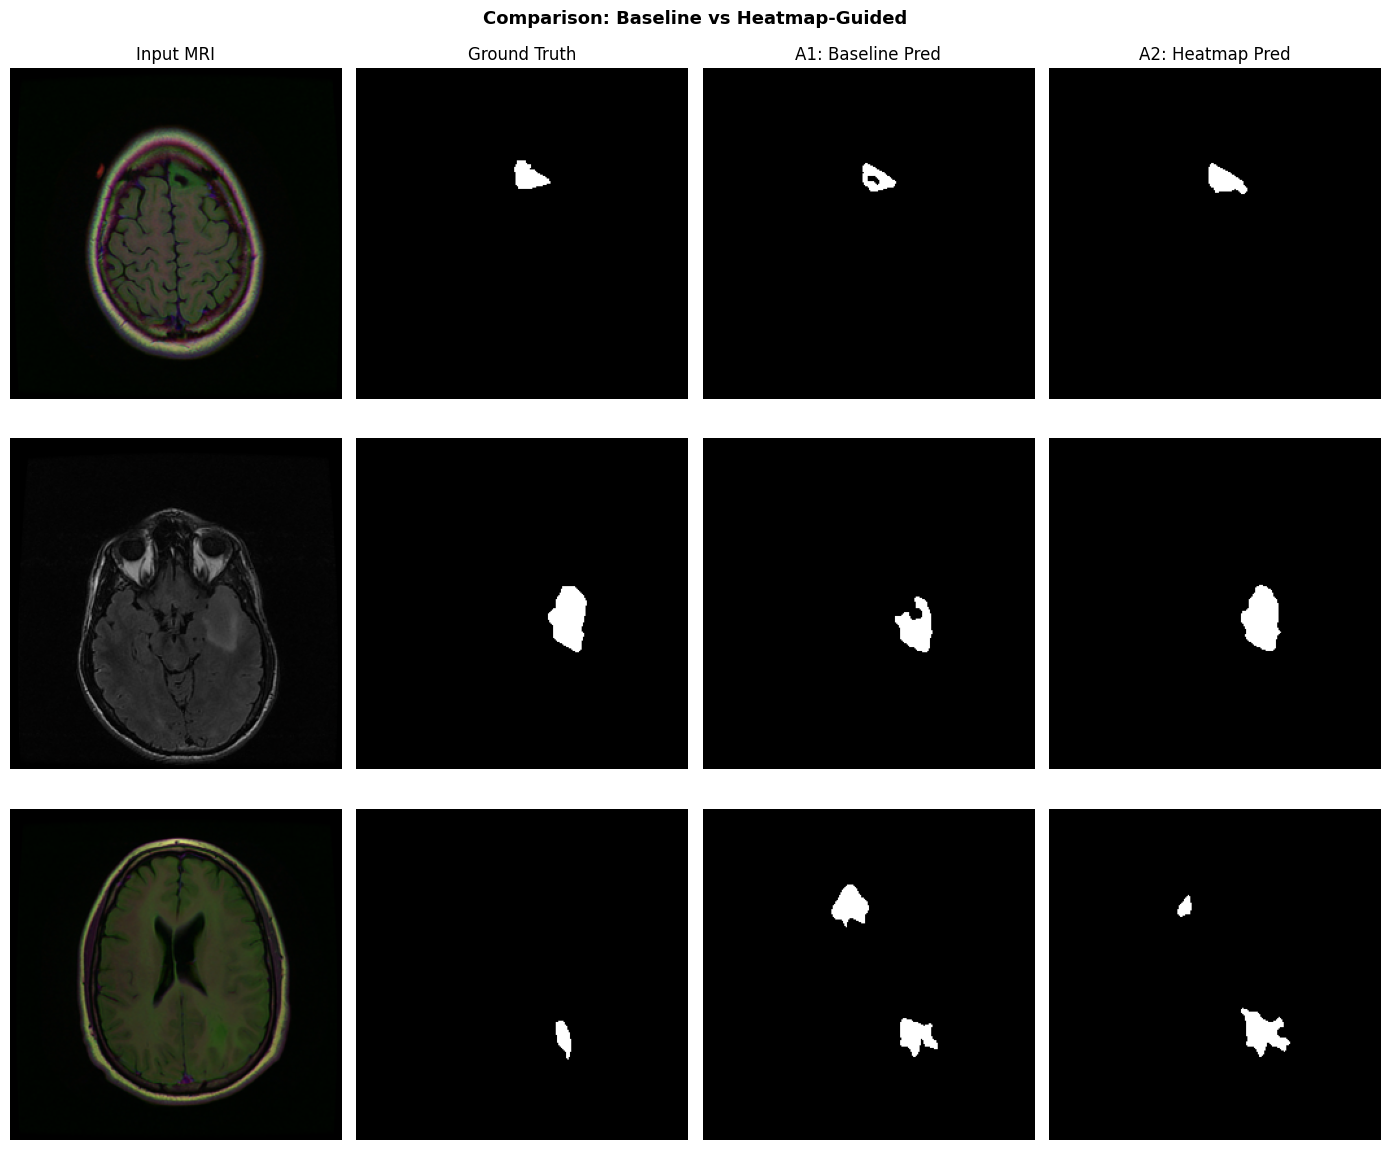

In [16]:
# Pick samples that exist in BOTH test datasets (they share the same pairs)
# We compare predictions on the same MRI for both approaches.

def visualize_comparison(model_a1, model_a2, dataset_a1, dataset_a2,
                          num_samples=3, threshold=0.5, save_path=None):
    """
    For the same sample index show:
      MRI | GT Mask | A1 Prediction | A2 Prediction
    This makes the visual effect of heatmap guidance immediately clear.
    """
    assert len(dataset_a1) == len(dataset_a2), \
        'Datasets must have the same length for direct comparison.'

    model_a1.eval()
    model_a2.eval()
    indices = random.sample(range(len(dataset_a1)), num_samples)

    fig, axes = plt.subplots(num_samples, 4, figsize=(14, 4 * num_samples))
    fig.suptitle('Comparison: Baseline vs Heatmap-Guided', fontsize=13, fontweight='bold')
    col_titles = ['Input MRI', 'Ground Truth', 'A1: Baseline Pred', 'A2: Heatmap Pred']

    for row, idx in enumerate(indices):
        img_a1, mask_a1 = dataset_a1[idx]   # (3, H, W), (1, H, W)
        img_a2, mask_a2 = dataset_a2[idx]   # (4, H, W), (1, H, W)

        with torch.no_grad():
            pred_a1 = (torch.sigmoid(model_a1(img_a1.unsqueeze(0).to(DEVICE))) > threshold)\
                      .float().cpu().squeeze().numpy()
            pred_a2 = (torch.sigmoid(model_a2(img_a2.unsqueeze(0).to(DEVICE))) > threshold)\
                      .float().cpu().squeeze().numpy()

        gt      = mask_a1.squeeze().cpu().numpy()
        img_disp = denormalize(img_a1[:3]).permute(1, 2, 0).numpy()

        # Metrics for both approaches
        def metrics(pred):
            p = torch.tensor(pred).unsqueeze(0).unsqueeze(0)
            t = torch.tensor(gt).unsqueeze(0).unsqueeze(0)
            return compute_dice_score(p, t), compute_iou(p, t)

        d1, i1 = metrics(pred_a1)
        d2, i2 = metrics(pred_a2)

        row_ax = axes[row] if num_samples > 1 else axes

        row_ax[0].imshow(img_disp)
        row_ax[0].set_title(col_titles[0] if row == 0 else '')
        row_ax[0].axis('off')

        row_ax[1].imshow(gt, cmap='gray')
        row_ax[1].set_title(col_titles[1] if row == 0 else '')
        row_ax[1].axis('off')

        row_ax[2].imshow(pred_a1, cmap='gray')
        row_ax[2].set_title(col_titles[2] if row == 0 else '')
        row_ax[2].set_xlabel(f'Dice: {d1:.3f}  IoU: {i1:.3f}', fontsize=9)
        row_ax[2].axis('off')

        row_ax[3].imshow(pred_a2, cmap='gray')
        row_ax[3].set_title(col_titles[3] if row == 0 else '')
        row_ax[3].set_xlabel(f'Dice: {d2:.3f}  IoU: {i2:.3f}', fontsize=9)
        row_ax[3].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


visualize_comparison(
    model_A1, model_A2,
    test_dataset_A1, test_dataset_A2,
    num_samples=3,
    save_path=os.path.join(OUTPUT_DIR, 'comparison_a1_vs_a2.png')
)